## Notebook for using the CDS API to get ERA5 data

#### Run the pip install to get the latest cdsapi

In [2]:
#!pip install cdsapi
!pip install --upgrade cdsapi
# created .cdsapirc file in ~/  per https://ads-beta.atmosphere.copernicus.eu/how-to-api

  Using cached cdsapi-0.7.7-py2.py3-none-any.whl.metadata (3.1 kB)
  Using cached ecmwf_datastores_client-0.5.0-py3-none-any.whl.metadata (21 kB)
  Using cached multiurl-0.3.7-py3-none-any.whl.metadata (2.8 kB)
Using cached cdsapi-0.7.7-py2.py3-none-any.whl (12 kB)
Using cached ecmwf_datastores_client-0.5.0-py3-none-any.whl (29 kB)
Using cached multiurl-0.3.7-py3-none-any.whl (21 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [cdsapi]


In [6]:
import cdsapi
import requests

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

### This block is for grabbing a single year, entire globe <br><br> This actually errors out and says the request is too large for netcdf, apparently

In [2]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            #'2m_temperature', 
            'land_sea_mask',
        ],
        'year': '2023',
        'month': [
            #'01', '02', '03',
            #'04', '05', '06',
            #'07', '08', 
            '09',
            #'10', '11', '12',
        ],
        'day': [
            '01', #'02', '03',
            # '04', '05', '06',
            # '07', '08', '09',
            # '10', '11', '12',
            # '13', '14', '15',
            # '16', '17', '18',
            # '19', '20', '21',
            # '22', '23', '24',
            # '25', '26', '27',
            # '28', '29', '30',
            # '31',
        ],
        'time': [
            # '00:00', '01:00', '02:00',
            # '03:00', '04:00', '05:00',
            # '06:00', '07:00', '08:00',
            # '09:00', '10:00', '11:00',
             '12:00', #'13:00', '14:00',
            # '15:00', '16:00', '17:00',
            # '18:00', '19:00', '20:00',
            # '21:00', '22:00', '23:00',
        ],
        'format': 'netcdf',
    },
    'ERA5-2023-09-01-Full-LSM-download.nc')

2024-07-04 15:47:39,562 INFO Welcome to the CDS
2024-07-04 15:47:39,562 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-07-04 15:47:39,841 INFO Request is queued
2024-07-04 15:47:42,704 INFO Request is completed
2024-07-04 15:47:42,705 INFO Downloading https://download-0018.copernicus-climate.eu/cache-compute-0018/cache/data5/adaptor.mars.internal-1720133261.933593-1638-18-449eb970-0a03-4b82-b836-fe806558723e.nc to ERA5-2023-09-01-Full-LSM-download.nc (2M)
2024-07-04 15:47:44,709 INFO Download rate 1016.7K/s                            


Result(content_length=2086240,content_type=application/x-netcdf,location=https://download-0018.copernicus-climate.eu/cache-compute-0018/cache/data5/adaptor.mars.internal-1720133261.933593-1638-18-449eb970-0a03-4b82-b836-fe806558723e.nc)

### This block is for specific years and months, specific area lat/lon

In [ ]:
# try multiple years, same region, JJA
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            '2m_temperature', 'land_sea_mask',
        ],
        'year': ['2020','2021','2022','2023'],
        'month': [
            '06', '07', '08',
        ],
        'day': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12',
            '13', '14', '15',
            '16', '17', '18',
            '19', '20', '21',
            '22', '23', '24',
            '25', '26', '27',
            '28', '29', '30',
            '31',
        ],
        'time': [
            '00:00', '01:00', '02:00',
            '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00',
            '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00',
            '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00',
            '21:00', '22:00', '23:00',
        ],
        'area': [
            50, -124, 47,
            -122,
        ],
        'format': 'netcdf',
    },
    '2020-2023_JJA_PugetSound_T2m-LSM.nc')

# *** below is for the old API

### <br> Using the Daily Statistics Application to get daily means instead of pulling hourly data and calculating it <br> https://cds.climate.copernicus.eu/cdsapp#!/software/app-c3s-daily-era5-statistics?tab=overview <br><br> From this forum post: https://forum.ecmwf.int/t/retrieve-daily-era5-era5-land-data-using-the-cds-api/1150/1 <br><br> After running - note each month is roughly 128MB or about 1.5GB per year! <br> 

In [ ]:
import cdsapi
import requests
 
# CDS API script to use CDS service to retrieve daily ERA5* variables and iterate over
# all months in the specified years.
 
# Requires:
# 1) the CDS API to be installed and working on your system
# 2) You have agreed to the ERA5 Licence (via the CDS web page)
# 3) Selection of required variable, daily statistic, etc
 
# Output:
# 1) separate netCDF file for chosen daily statistic/variable for each month
 
c = cdsapi.Client()#timeout=300)
 
# Uncomment years as required
 
years =  [
#    '1960',
#    '1961','1962','1963','1964'
#   '1965','1966',
#    '1967',
#    '1968',
#     '1969',
#            '1970',
#    '1971','1972','1973','1974','1975',
#    '1976','1977','1978','1979',
#            '1980', 
#    '1981','1982', '1983', '1984',
#            '1985',
# '1986', '1987','1988', '1989', 
#    '1990'#,
  #          '1991', '1992', '1993',
  #          '1994', '1995', '1996',
  #          '1997', '1998', '1999',
  #         '2000',
  #  '2001', '2002',
  #          '2003', '2004', '2005',
  #          '2006', '2007', '2008',
  #          '2009', 
  # '2010', 
   # '2011',
   #          '2012', '2013', '2014',
   #          '2015', '2016', '2017',
   #          '2018', '2019', '2020',
   #         '2021',
   #          '2022',
   # '2023',
   #  '2024'
]
 
 
# Retrieve all months for a given year.
 
months = ['01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12']
 
# For valid keywords, see Table 2 of:
# https://datastore.copernicus-climate.eu/documents/app-c3s-daily-era5-statistics/C3S_Application-Documentation_ERA5-daily-statistics-v2.pdf
 
# select your variable; name must be a valid ERA5 CDS API name.
var = "sea_surface_temperature" #"2m_temperature"
 
# Select the required statistic, valid names given in link above
stat = "daily_mean"
 
# Loop over years and months
 
for yr in years:
    for mn in months:
        result = c.service(
        "tool.toolbox.orchestrator.workflow",
        params={
             "realm": "user-apps",
             "project": "app-c3s-daily-era5-statistics",
             "version": "master",
             "kwargs": {
                 "dataset": "reanalysis-era5-single-levels",
                 "product_type": "reanalysis",
                 "variable": var,
                 "statistic": stat,
                 "year": yr,
                 "month": mn,
                 "time_zone": "UTC+00:0",
                 "frequency": "1-hourly",
#
# Users can change the output grid resolution and selected area
#
#                "grid": "1.0/1.0",
#                "area":{"lat": [10, 60], "lon": [65, 140]}
 
                 },
        "workflow_name": "application"
        })
         
# set name of output file for each month (statistic, variable, year, month     
 
        file_name = "../../../Data/ERA5-global/Analysis/" + yr + "/download_" + stat + "_" + var + "_" + yr + "_" + mn + ".nc"
         
        location=result[0]['location']
        res = requests.get(location, stream = True)
        print("Writing data to " + file_name)
        with open(file_name,'wb') as fh:
            for r in res.iter_content(chunk_size = 1024):
                fh.write(r)
        fh.close()

# *** new API starts here

## Pull daily stats by month for desired years

In [14]:
# modified example code from https://confluence.ecmwf.int/display/CKB/ERA5+family+post-processed+daily+statistics+documentation

years = [ "2025",# "2026"
        ]

months = [
        "01", 
    "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
        ]

var = '2m_temperature'

stat = 'daily_mean'

for yr in years:
    for mn in months:

        dataset = "derived-era5-single-levels-daily-statistics"
        request = {
            "product_type": "reanalysis",
            "variable": var,
            "year": yr,
            "month": mn,
            "day": [
                "01", "02", "03",
                "04", "05", "06",
                "07", "08", "09",
                "10", "11", "12",
                "13", "14", "15",
                "16", "17", "18",
                "19", "20", "21",
                "22", "23", "24",
                "25", "26", "27",
                "28", "29", "30",
                "31"
            ],
            "daily_statistic": stat,
            "time_zone": "utc+00:00",
            "frequency": "1_hourly"
        }
        target = "../../../Data/ERA5-global/Analysis/" + yr + "/download_" + stat + "_" + var + "_" + yr + "_" + mn + ".nc"
        client = cdsapi.Client()
        client.retrieve(dataset, request, target)#.download()
        

2026-03-20 15:49:26,741 INFO Request ID is 046e43ca-5e68-4938-85fa-2d8b86bbeae4
2026-03-20 15:49:26,962 INFO status has been updated to accepted
2026-03-20 15:49:36,078 INFO status has been updated to running
2026-03-20 15:49:41,346 INFO status has been updated to successful


a807256fb931a493d2e84e6349436135.nc:   0%|          | 0.00/76.7M [00:00<?, ?B/s]

2026-03-20 15:49:51,456 INFO Request ID is 45e24f19-caa9-4865-aa5e-6899e298c969
2026-03-20 15:49:51,663 INFO status has been updated to accepted
2026-03-20 15:50:06,007 INFO status has been updated to running
2026-03-20 15:50:13,824 INFO status has been updated to successful


f09560190c36354c34d0a5dbde287bc7.nc:   0%|          | 0.00/65.7M [00:00<?, ?B/s]

2026-03-20 15:50:22,699 INFO Request ID is 8b1a18dd-df25-4d6c-b7f6-3add3a015130
2026-03-20 15:50:22,919 INFO status has been updated to accepted
2026-03-20 15:50:45,059 INFO status has been updated to successful


...

5087c9914ddedd9f3335eaf167397142.nc:   0%|          | 0.00/65.9M [00:00<?, ?B/s]

2026-03-20 15:54:18,730 INFO Request ID is 2a023b72-04a5-4356-87ce-313e9ee2b63f
2026-03-20 15:54:18,937 INFO status has been updated to accepted
2026-03-20 15:54:33,233 INFO status has been updated to successful


ef80730a85c6b62d9476129ce48ca94a.nc:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

2026-03-20 15:54:42,036 INFO Request ID is 236833c3-2d94-4230-af2c-d38e3fe5e053
2026-03-20 15:54:42,248 INFO status has been updated to accepted
2026-03-20 15:54:56,594 INFO status has been updated to successful


41e789ce4fa99be8bbbe26b57710f121.nc:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

In [64]:
# filename ERA5_T2m_202106_PugetSound.nc
dset = xr.open_dataset('../../../Data/ERA5-global/Analysis/2024/download_daily_mean_2m_temperature_2024_01.nc')
dset

<xarray.Dataset> Size: 129MB
Dimensions:      (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 248B 2024-01-01 2024-01-02 ... 2024-01-31
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    realization  int64 8B ...
Data variables:
    t2m          (time, lat, lon) float32 129MB ...
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-07-11T19:33 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [74]:
dset2 = xr.open_dataset('../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_01.nc')
dset2

<xarray.Dataset> Size: 129MB
Dimensions:  (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2025-01-01 2025-01-02 ... 2025-01-31
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    number   int64 8B ...
Data variables:
    t2m      (time, lat, lon) float32 129MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T06:31 GRIB to CDM+CF via cfgrib-0.9.1...

/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


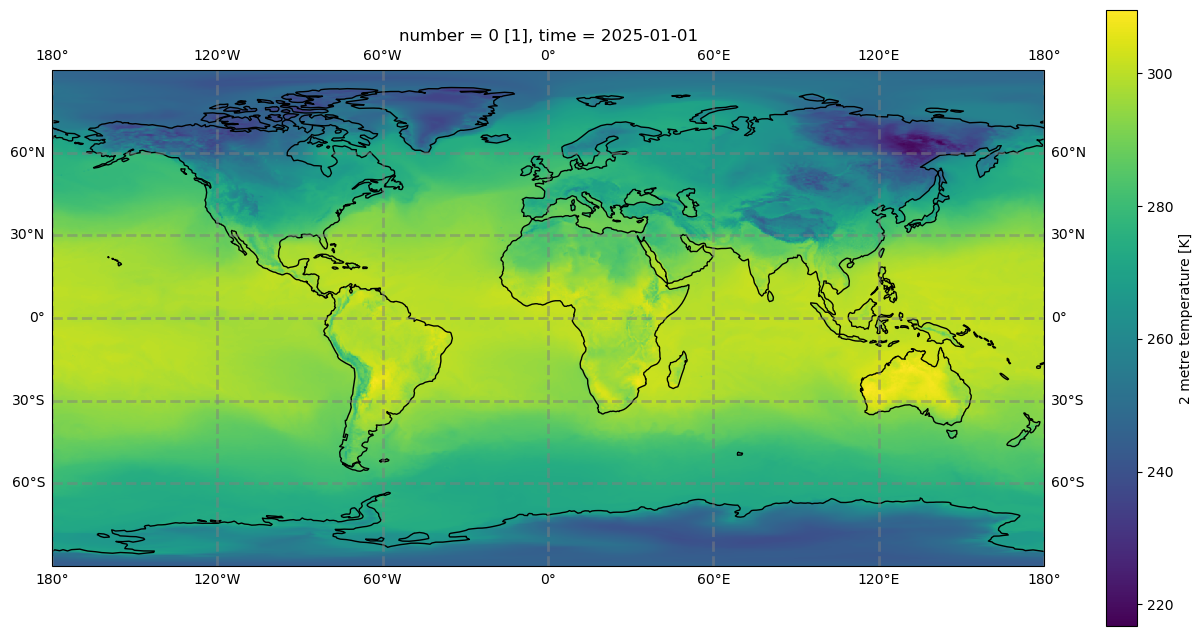

In [76]:
fig = plt.figure(figsize=[16,8])

# 111 means 1 row, 1 col and index 1
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree(central_longitude=0))
dset2.t2m.isel(time=0).plot(ax=ax,transform=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)

plt.show()

## CDS changed the variable names and the longitude basis for ERA5 daily mean data! Need to shift and rename

In [77]:

dset2

<xarray.Dataset> Size: 129MB
Dimensions:  (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2025-01-01 2025-01-02 ... 2025-01-31
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    number   int64 8B ...
Data variables:
    t2m      (time, lat, lon) float32 129MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T06:31 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = dset2.coords['longitude'].attrs  
lat_atrib = dset2.coords['latitude'].attrs
time_atrib = dset2.coords['valid_time'].attrs
dset2.coords['longitude'] = (dset2.coords['longitude'] + 180) % 360 - 180
dset2 = dset2.sortby(dset2.longitude)
dset2

In [80]:
# now adjust latitude to run from -90 to 90 like my pre-2025 data
# help from https://stackoverflow.com/questions/54677161/xarray-reverse-an-array-along-one-coordinate

dset2 = dset2.isel(lat=slice(None, None, -1))
#dset2 = dset2.reindex(lat=dset2.lat[::-1])
dset2

<xarray.Dataset> Size: 129MB
Dimensions:  (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2025-01-01 2025-01-02 ... 2025-01-31
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    number   int64 8B ...
Data variables:
    t2m      (time, lat, lon) float32 129MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T06:31 GRIB to CDM+CF via cfgrib-0.9.1...

In [81]:
# also save that out because that is how I will want the longitude
# also rename to lat and lon like the t2m data
#ds = dset2.rename({'valid_time':'time','longitude':'lon','latitude':'lat'})
ds = dset2.rename({'time':'time','lon':'lon','lat':'lat'})
ds.coords['lon'].attrs = lon_atrib
ds.coords['lat'].attrs = lat_atrib
ds.coords['time'].attrs = time_atrib
output_path = '../../../Data/ERA5-global/Analysis/2025/fixed/download_daily_mean_2m_temperature_2025_01.nc'
ds.to_netcdf(output_path)
ds

<xarray.Dataset> Size: 129MB
Dimensions:  (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2025-01-01 2025-01-02 ... 2025-01-31
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    number   int64 8B ...
Data variables:
    t2m      (time, lat, lon) float32 129MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T06:31 GRIB to CDM+CF via cfgrib-0.9.1...

/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


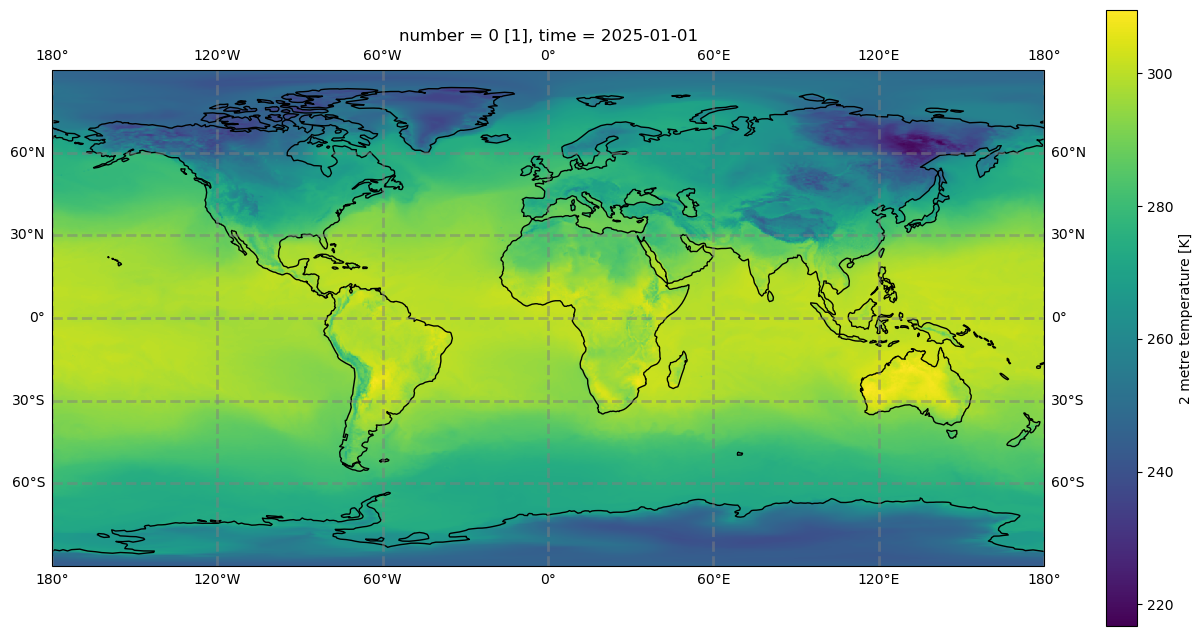

In [82]:
# map it again for comparison
fig = plt.figure(figsize=[16,8])

# 111 means 1 row, 1 col and index 1
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree(central_longitude=0))
ds.t2m.isel(time=0).plot(ax=ax,transform=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)

plt.show()

# ***

## Looks like adjusting coordinates works! now need to loop thru all remaining months to clean them up 

In [83]:
!ls -al "../../../Data/ERA5-global/Analysis/2025/"

total 1700008
drwxr-xr-x@ 15 tedscott  staff       480 Mar 24 10:07 .
drwx------@ 41 tedscott  staff      1312 Mar 20 15:42 ..
-rw-r--r--@  1 tedscott  staff  61651371 Mar 20 16:15 download_daily_mean_2m_temperature_2025_01.nc
-rw-r--r--@  1 tedscott  staff  68940612 Mar 20 15:50 download_daily_mean_2m_temperature_2025_02.nc
-rw-r--r--@  1 tedscott  staff  73615571 Mar 20 15:50 download_daily_mean_2m_temperature_2025_03.nc
-rw-r--r--@  1 tedscott  staff  72564303 Mar 20 15:51 download_daily_mean_2m_temperature_2025_04.nc
-rw-r--r--@  1 tedscott  staff  73895688 Mar 20 15:51 download_daily_mean_2m_temperature_2025_05.nc
-rw-r--r--@  1 tedscott  staff  74223669 Mar 20 15:52 download_daily_mean_2m_temperature_2025_06.nc
-rw-r--r--@  1 tedscott  staff  74650611 Mar 20 15:52 download_daily_mean_2m_temperature_2025_07.nc
-rw-r--r--@  1 tedscott  staff  81952454 Mar 20 15:53 download_daily_mean_2m_temperature_2025_08.nc
-rw-r--r--@  1 tedscott  staff  75419369 Mar 20 15:53 download_daily_mean

In [50]:
import glob

filelist = glob.glob(r"../../../Data/ERA5-global/Analysis/2025/*.nc")
fixme = np.sort(filelist)[1:]
print(fixme)


['../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_02.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_03.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_04.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_05.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_06.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_07.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_08.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_09.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_10.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_11.nc'
 '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_12.nc']


In [53]:
for i,j in zip(months,fixme):
    print(i,j)

2 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_02.nc
3 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_03.nc
4 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_04.nc
5 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_05.nc
6 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_06.nc
7 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_07.nc
8 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_08.nc
9 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_09.nc
10 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_10.nc
11 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_11.nc
12 ../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_12.nc


In [86]:
# list of months to shift lat and lon, and rename time var
months = [
        #"01", 
    "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
        ]

# build filenames and loop

for m in months:
    filepath = '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_' + str(m) + '.nc'
    ds = xr.open_dataset(filepath)

    # adjust longitude to run from -180 to 180
    lon_atrib = ds.coords['longitude'].attrs  
    lat_atrib = ds.coords['latitude'].attrs
    time_atrib = ds.coords['valid_time'].attrs
    ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
    ds = ds.sortby(ds.longitude)

    # now adjust latitude to run from -90 to 90 like my pre-2025 data
    ds = ds.isel(latitude=slice(None, None, -1))

    # rename to lat and lon like the t2m data and update attributes
    dst = ds.rename({'valid_time':'time','longitude':'lon','latitude':'lat'})
    dst.coords['lon'].attrs = lon_atrib
    dst.coords['lat'].attrs = lat_atrib
    dst.coords['time'].attrs = time_atrib

    # save it out 
    outpath = '../../../Data/ERA5-global/Analysis/2025/fixed/download_daily_mean_2m_temperature_2025_' + str(m) + '.nc'
    dst.to_netcdf(outpath)

In [87]:
!ls -al "../../../Data/ERA5-global/Analysis/2025"

total 1700008
drwxr-xr-x@ 15 tedscott  staff       480 Mar 24 10:07 .
drwx------@ 41 tedscott  staff      1312 Mar 20 15:42 ..
-rw-r--r--@  1 tedscott  staff  61651371 Mar 20 16:15 download_daily_mean_2m_temperature_2025_01.nc
-rw-r--r--@  1 tedscott  staff  68940612 Mar 20 15:50 download_daily_mean_2m_temperature_2025_02.nc
-rw-r--r--@  1 tedscott  staff  73615571 Mar 20 15:50 download_daily_mean_2m_temperature_2025_03.nc
-rw-r--r--@  1 tedscott  staff  72564303 Mar 20 15:51 download_daily_mean_2m_temperature_2025_04.nc
-rw-r--r--@  1 tedscott  staff  73895688 Mar 20 15:51 download_daily_mean_2m_temperature_2025_05.nc
-rw-r--r--@  1 tedscott  staff  74223669 Mar 20 15:52 download_daily_mean_2m_temperature_2025_06.nc
-rw-r--r--@  1 tedscott  staff  74650611 Mar 20 15:52 download_daily_mean_2m_temperature_2025_07.nc
-rw-r--r--@  1 tedscott  staff  81952454 Mar 20 15:53 download_daily_mean_2m_temperature_2025_08.nc
-rw-r--r--@  1 tedscott  staff  75419369 Mar 20 15:53 download_daily_mean

In [88]:
!ls -al "../../../Data/ERA5-global/Analysis/2025/fixed"

total 1413312
drwxr-xr-x@ 14 tedscott  staff       448 Mar 24 10:26 .
drwxr-xr-x@ 15 tedscott  staff       480 Mar 24 10:07 ..
-rw-r--r--@  1 tedscott  staff  61638692 Mar 24 10:31 download_daily_mean_2m_temperature_2025_01.nc
-rw-r--r--@  1 tedscott  staff  55764585 Mar 24 10:35 download_daily_mean_2m_temperature_2025_02.nc
-rw-r--r--@  1 tedscott  staff  61886015 Mar 24 10:35 download_daily_mean_2m_temperature_2025_03.nc
-rw-r--r--@  1 tedscott  staff  59440870 Mar 24 10:35 download_daily_mean_2m_temperature_2025_04.nc
-rw-r--r--@  1 tedscott  staff  61244331 Mar 24 10:35 download_daily_mean_2m_temperature_2025_05.nc
-rw-r--r--@  1 tedscott  staff  59107302 Mar 24 10:35 download_daily_mean_2m_temperature_2025_06.nc
-rw-r--r--@  1 tedscott  staff  61323160 Mar 24 10:35 download_daily_mean_2m_temperature_2025_07.nc
-rw-r--r--@  1 tedscott  staff  61290138 Mar 24 10:35 download_daily_mean_2m_temperature_2025_08.nc
-rw-r--r--@  1 tedscott  staff  59216065 Mar 24 10:35 download_daily_mean

In [89]:
# check the last file to make sure it is correct
dst

<xarray.Dataset> Size: 129MB
Dimensions:  (time: 31, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 248B 2025-12-01 2025-12-02 ... 2025-12-31
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    number   int64 8B ...
Data variables:
    t2m      (time, lat, lon) float32 129MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-20T07:17 GRIB to CDM+CF via cfgrib-0.9.1...

/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/summer/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


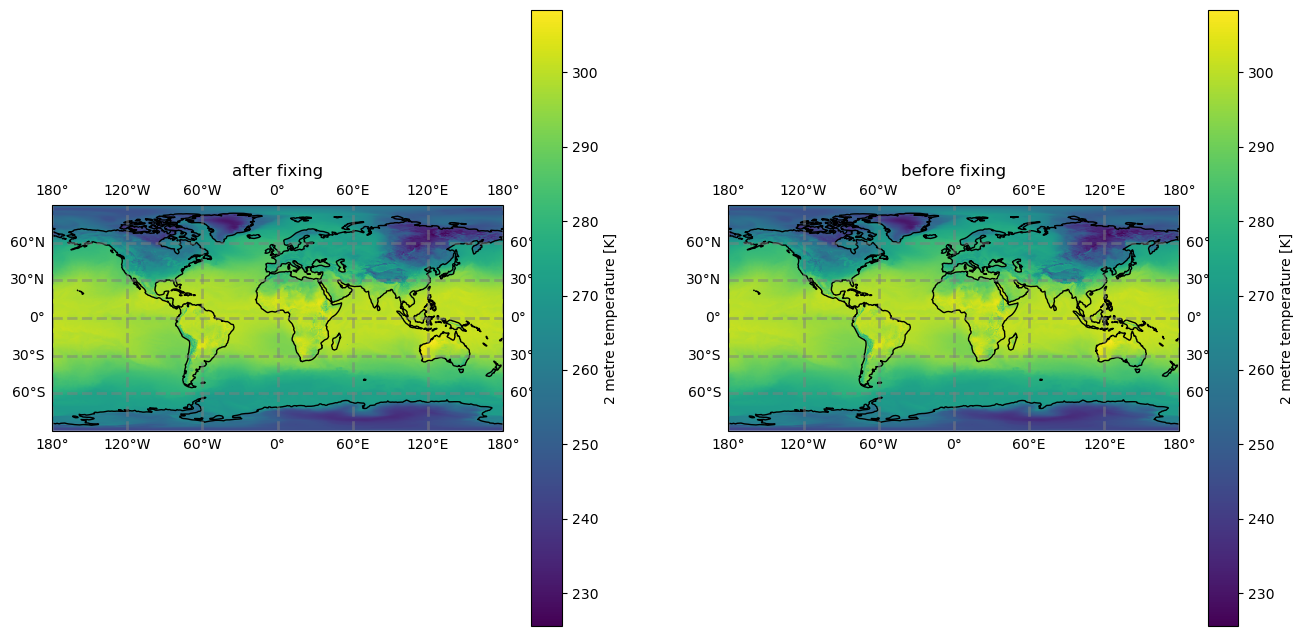

In [92]:
# quick plot comparisons
#before reindexing dimensions
filepath = '../../../Data/ERA5-global/Analysis/2025/download_daily_mean_2m_temperature_2025_12.nc'
ds = xr.open_dataset(filepath)

# map it again for comparison
fig = plt.figure(figsize=[16,8])

# 111 means 1 row, 1 col and index 1
ax1 = fig.add_subplot(1,2,1, projection=ccrs.PlateCarree(central_longitude=0))
dst.t2m.isel(time=0).plot(ax=ax1,transform=ccrs.PlateCarree())
ax1.coastlines()
gl = ax1.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)
ax1.set_title("after fixing")

ax2 = fig.add_subplot(1,2,2, projection=ccrs.PlateCarree(central_longitude=0))
ds.t2m.isel(valid_time=0).plot(ax=ax2,transform=ccrs.PlateCarree())
ax2.coastlines()
gl = ax2.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)
ax2.set_title("before fixing")


plt.show()

In [93]:
ds, dst

(<xarray.Dataset> Size: 129MB
 Dimensions:     (valid_time: 31, latitude: 721, longitude: 1440)
 Coordinates:
   * valid_time  (valid_time) datetime64[ns] 248B 2025-12-01 ... 2025-12-31
   * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
   * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
     number      int64 8B ...
 Data variables:
     t2m         (valid_time, latitude, longitude) float32 129MB ...
 Attributes:
     GRIB_centre:             ecmf
     GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
     GRIB_subCentre:          0
     Conventions:             CF-1.7
     institution:             European Centre for Medium-Range Weather Forecasts
     history:                 2026-03-20T07:17 GRIB to CDM+CF via cfgrib-0.9.1...,
 <xarray.Dataset> Size: 129MB
 Dimensions:  (time: 31, lat: 721, lon: 1440)
 Coordinates:
   * time     (time) datetime64[ns] 248B 2025-12-01 2025-12-02 ... 2025-12-31
   * la

# OK, the fixing of dimension labels and indexing worked!

In [4]:
!ls -al "../../../Data/ERA5-global/Analysis/2024/"

total 3578240
drwxr-xr-x@ 17 tedscott  staff        544 Sep  1 22:28 .
drwxr-xr-x@ 39 tedscott  staff       1248 Aug 30 11:36 ..
-rw-r--r--@  1 tedscott  staff  128778531 Jul 23 15:15 download_daily_mean_2m_temperature_2024_01.nc
-rw-r--r--@  1 tedscott  staff  120472595 Jul 23 15:18 download_daily_mean_2m_temperature_2024_02.nc
-rw-r--r--@  1 tedscott  staff  128778532 Jul 23 15:22 download_daily_mean_2m_temperature_2024_03.nc
-rw-r--r--@  1 tedscott  staff  124625564 Jul 23 15:23 download_daily_mean_2m_temperature_2024_04.nc
-rw-r--r--@  1 tedscott  staff  128778534 Jul 23 15:23 download_daily_mean_2m_temperature_2024_05.nc
-rw-r--r--@  1 tedscott  staff  124625566 Jul 23 15:23 download_daily_mean_2m_temperature_2024_06.nc
-rw-r--r--@  1 tedscott  staff   74789948 Jul 23 15:23 download_daily_mean_2m_temperature_2024_07.nc
-rw-r--r--@  1 tedscott  staff  128778531 Sep  1 22:02 download_daily_mean_sea_surface_temperature_2024_01.nc
-rw-r--r--@  1 tedscott  staff  120472597 Sep  1 22:06

## **** OLD NOT UPDATED
### Get Satellite Ocean Color Data for Salome and Risako

In [ ]:
import cdsapi
import requests

# try multiple years, specific region including Galapagos
c = cdsapi.Client()

c.retrieve(
    'satellite-ocean-colour',
    {
        'version': '6_0',
        'format': 'zip',
        'variable': [
            'mass_concentration_of_chlorophyll_a',
        ],
        'projection': 'regular_latitude_longitude_grid',
        'year': ['2019',
                 #'2020','2021','2022','2023',
                ],
        'month': [
            '01', '02', '03','04','05','06','07','08','09','10','11','12',
        ],
        'day': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12',
            '13', '14', '15',
            '16', '17', '18',
            '19', '20', '21',
            '22', '23', '24',
            '25', '26', '27',
            '28', '29', '30',
            '31',
        ],
        'area': [
            2, -92, -2,
            -88,
        ],
        'format': 'netcdf',
    },
    '2019-2023_OceanColour.nc')